# QSVT Polynomial Design and Approximation

In this notebook we address a natural next question:

> How do we design the polynomial used in QSVT?

Earlier notebooks used hand-picked polynomials:

- f(x) = x²
- f(x) = x
- f(x) = x³
- T₃(x) = 4x³ − 3x

QSVT becomes powerful when we can systematically approximate useful
functions using bounded polynomials.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qsvt.design import design_inverse_polynomial
from qsvt.polynomials import (
    chebyshev_t,
    eval_polynomial,
)

from qsvt.approximation import (
    chebyshev_fit_function,
    max_error,
)

## 1. Why QSVT uses polynomials

QSVT implements polynomial transformations because quantum circuits
are unitary and therefore bounded.

Any admissible function must satisfy:

|f(x)| ≤ 1  for x in [-1,1].

Therefore many useful functions must be approximated by bounded polynomials.

## 2. Chebyshev polynomials

Chebyshev polynomials satisfy:

T_n(x) = cos(n arccos x)

and obey:

|T_n(x)| ≤ 1   on [-1,1]

making them natural building blocks for QSVT polynomials.

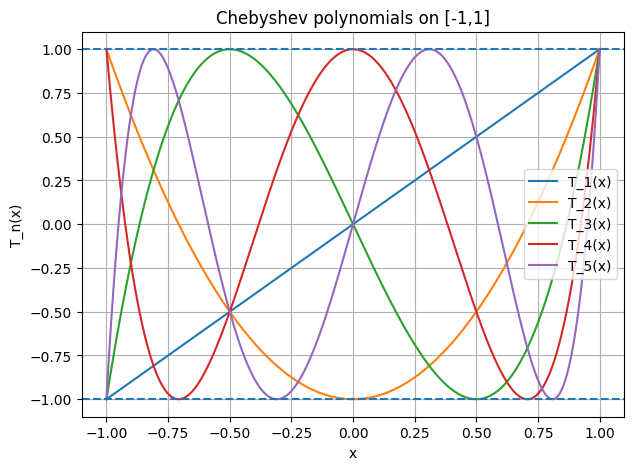

In [2]:
x = np.linspace(-1, 1, 400)

plt.figure(figsize=(7, 5))

for n in [1, 2, 3, 4, 5]:
    plt.plot(x, chebyshev_t(n, x), label=f"T_{n}(x)")

plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")

plt.title("Chebyshev polynomials on [-1,1]")
plt.xlabel("x")
plt.ylabel("T_n(x)")

plt.grid(True)
plt.legend()

plt.show()

## 3. Approximating inverse-like behaviour

The inverse function 1/x is unbounded near zero.

If eigenvalues satisfy:

|λ| ≥ a > 0

we only need to approximate 1/x on:

[-1,-a] ∪ [a,1]

which allows bounded polynomial approximations.

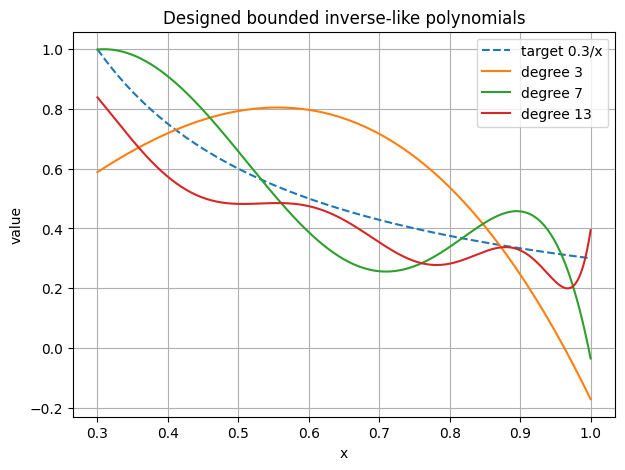

In [3]:
a = 0.3


def scaled_inv(x):
    return a / x


xs = np.linspace(a, 1.0, 400)

plt.figure(figsize=(7, 5))
plt.plot(xs, scaled_inv(xs), "--", label=f"target {a}/x")

for deg in [3, 7, 13]:
    coeffs = design_inverse_polynomial(gamma=a, degree=deg)
    approx = eval_polynomial(coeffs, xs)
    plt.plot(xs, approx, label=f"degree {deg}")

plt.title("Designed bounded inverse-like polynomials")
plt.xlabel("x")
plt.ylabel("value")
plt.grid(True)
plt.legend()
plt.show()

## 4. Approximation error vs degree

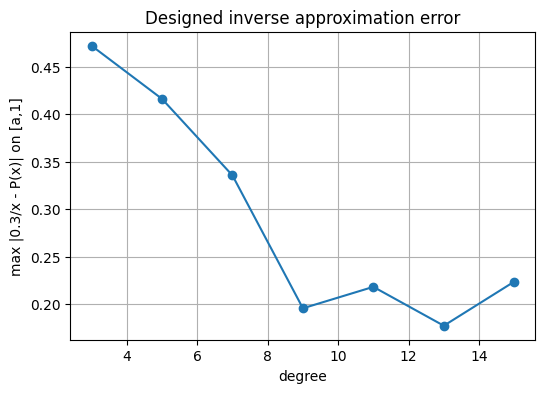

In [4]:
degrees = [3, 5, 7, 9, 11, 13, 15]
errors = []
bounded_maxima = []

for deg in degrees:
    coeffs = design_inverse_polynomial(gamma=a, degree=deg)

    x_bound = np.linspace(-1.0, 1.0, 2001)
    vals_bound = eval_polynomial(coeffs, x_bound)
    bounded_maxima.append(float(np.max(np.abs(vals_bound))))

    def approx_fn(x, coeffs=coeffs):
        return eval_polynomial(coeffs, x)

    err = max_error(
        scaled_inv,
        approx_fn,
        domain=(a, 1.0),
        num_points=1000,
    )
    errors.append(err)

best_error = min(errors)
best_degree = degrees[int(np.argmin(errors))]

plt.figure(figsize=(6, 4))
plt.plot(degrees, errors, "o-")
plt.xlabel("degree")
plt.ylabel(f"max |{a}/x - P(x)| on [a,1]")
plt.title("Designed inverse approximation error")
plt.grid(True)
plt.show()

The error is not guaranteed to decrease monotonically for this lightweight educational fitter, but the design helper keeps the polynomial bounded while producing useful inverse-like behavior on the safe spectral interval.


## Summary

QSVT works by implementing bounded polynomial transformations.

Chebyshev polynomials provide:

- boundedness on [-1,1]
- efficient approximation properties
- controlled tradeoff between degree and accuracy

Polynomial design is therefore central to practical QSVT algorithms.

## Validation

Compact checks for the expected tutorial behavior.


In [5]:
assert all(maximum <= 1.0 + 1e-8 for maximum in bounded_maxima)
assert best_error < 0.2
assert errors[0] > best_error

print(f"best_degree: {best_degree}")
print(f"best_inverse_error: {best_error:.3e}")
print(f"max_bounded_value: {max(bounded_maxima):.6f}")
print("validation: passed")

best_degree: 13
best_inverse_error: 1.775e-01
max_bounded_value: 1.000000
validation: passed
